In [94]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import io
import pickle as _pickle
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import product

import modal

from src.backtest import backtest

# Requires: modal deploy ../modal_train.py  (run once from the project root)
train_xgboost_fn       = modal.Function.from_name('regime-trading-model', 'train_xgboost')
train_xgboost_fixed_fn = modal.Function.from_name('regime-trading-model', 'train_xgboost_fixed')

def _decode_attr(value):
    if isinstance(value, dict) and value.get('__attr_type__') == 'dataframe_parquet':
        return pd.read_parquet(io.BytesIO(value['data']))
    return value

def _load_preds(raw: bytes) -> pd.DataFrame:
    """Deserialize Modal result → DataFrame with .attrs restored."""
    result = _pickle.loads(raw)
    preds = pd.read_parquet(io.BytesIO(result['preds']))
    for k, v in result.get('attrs', {}).items():
        preds.attrs[k] = _decode_attr(v)
    return preds

print('Modal ready.')

Modal ready.


In [95]:
df = pd.read_parquet('../data/model_data.parquet')

x_cols = [c for c in df.columns if c.startswith('x')]
cond_cols = [c for c in df.columns if c.startswith('con')]

df['cond2'] = df['cond2'].ffill().bfill()
df['cond3'] = df['cond3'].ffill().bfill()

print(f'Features: {len(x_cols)}, Cond cols: {len(cond_cols)}, Rows: {len(df):,}')

Features: 8, Cond cols: 3, Rows: 2,776,038


## 1. Baseline run (fixed split: train ≤ 2021, validate 2022-01-01 to 2023-06-30)

Trains once on all data through end of 2021; predicts the validation period from 2022-01-01 to 2023-06-30.
No retraining across validation/search stages — same split used for all HP search stages.

Default config: `max_depth=4, n_estimators=500, learning_rate=0.05, subsample=0.6, colsample_bytree=0.8, min_child_weight=100, reg_alpha=0.1`

`interaction_constraints`: each x feature can only interact with cond features — never with other x features. Each tree specializes in one alpha signal, optionally regime-conditioned.

Early stopping: inner validation annualized daily Sharpe, patience=25. Inner validation = last 25% of training data chronologically.


In [96]:
all_preds = {}  # key: (stage_tag, *params) -> {'preds', 'sharpe', 'return', 'eval_results'}

XGB_TRAIN_END_YEAR = 2021
XGB_VAL_YEARS = [2022, 2023]
XGB_VAL_START = '2022-01-01'
XGB_VAL_END = '2023-06-30'
XGB_TEST_START = '2023-07-01'
XGB_TEST_END = None

baseline_params = {
    'max_depth': 4,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'subsample': 0.6,
    'colsample_bytree': 0.8,
    'min_child_weight': 100,
    'reg_alpha': 0.1,
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'verbosity': 0,
}

print(f'Running baseline fixed-split (train <= {XGB_TRAIN_END_YEAR}, val {XGB_VAL_START} to {XGB_VAL_END})...')
print(f'Params: {baseline_params}')
preds_baseline = _load_preds(train_xgboost_fixed_fn.remote(
    xgb_params=baseline_params,
    train_end_year=XGB_TRAIN_END_YEAR,
    val_years=XGB_VAL_YEARS,
    val_start=XGB_VAL_START,
    val_end=XGB_VAL_END,
    verbose=True,
))

dd = preds_baseline.merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')
bt = backtest(dd, feature_col='pred', ret_col='ret_fopen')
print(f'Baseline Sharpe: {bt["sharpe_ratio"]:.4f}  return: {bt["average_return"]:.6f}  (val {XGB_VAL_START} to {XGB_VAL_END})')


Running baseline fixed-split (train <= 2021, val 2022-01-01 to 2023-06-30)...
Params: {'max_depth': 4, 'n_estimators': 500, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 100, 'reg_alpha': 0.1, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'verbosity': 0}
Baseline Sharpe: 1.0755  return: 0.001675  (val 2022-01-01 to 2023-06-30)


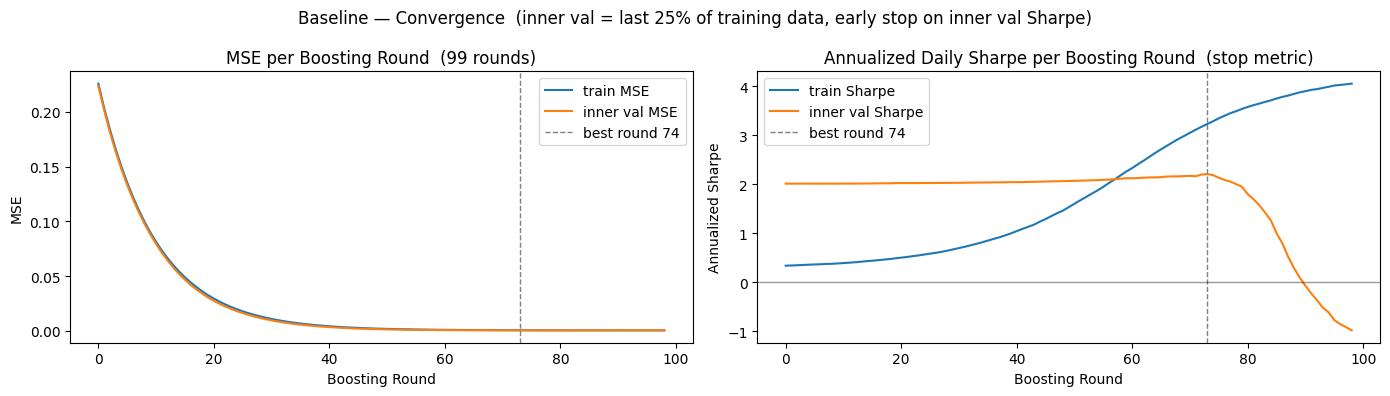

Best round: 74  |  train MSE=0.000471  iv MSE=0.000395  |  train Sharpe=3.2298  iv Sharpe=2.2087


In [97]:
eval_results = preds_baseline.attrs.get('eval_results', {})
best_iter = preds_baseline.attrs.get('best_iteration')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(
    'Baseline — Convergence  (inner val = last 25% of training data, early stop on inner val Sharpe)',
    fontsize=12,
)

if eval_results and 'train' in eval_results:
    n_rounds = len(eval_results['train']['mse'])
    stop = best_iter if best_iter is not None else n_rounds - 1

    axes[0].plot(eval_results['train']['mse'], label='train MSE')
    axes[0].plot(eval_results['inner_val']['mse'], label='inner val MSE')
    axes[0].axvline(stop, color='gray', lw=1, ls='--', label=f'best round {stop + 1}')
    axes[0].set_title(f'MSE per Boosting Round  ({n_rounds} rounds)')
    axes[0].set_xlabel('Boosting Round')
    axes[0].set_ylabel('MSE')
    axes[0].legend()

    axes[1].plot(eval_results['train']['sharpe'], label='train Sharpe')
    axes[1].plot(eval_results['inner_val']['sharpe'], label='inner val Sharpe')
    axes[1].axvline(stop, color='gray', lw=1, ls='--', label=f'best round {stop + 1}')
    axes[1].axhline(0, color='black', lw=1, alpha=0.4)
    axes[1].set_title('Annualized Daily Sharpe per Boosting Round  (stop metric)')
    axes[1].set_xlabel('Boosting Round')
    axes[1].set_ylabel('Annualized Sharpe')
    axes[1].legend()
else:
    axes[0].set_axis_off()
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

if eval_results and 'train' in eval_results and best_iter is not None:
    print(
        f'Best round: {best_iter + 1}  |  '
        f'train MSE={eval_results["train"]["mse"][best_iter]:.6f}  '
        f'iv MSE={eval_results["inner_val"]["mse"][best_iter]:.6f}  |  '
        f'train Sharpe={eval_results["train"]["sharpe"][best_iter]:.4f}  '
        f'iv Sharpe={eval_results["inner_val"]["sharpe"][best_iter]:.4f}'
    )

Baseline inner-val  Sharpe: 2.0639  Return: 0.002583  (2020–2021)


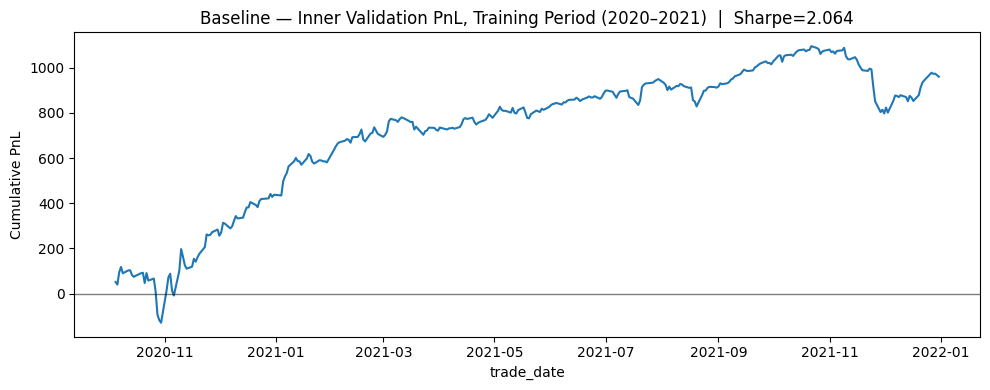

Baseline real-val   Sharpe: 1.0755  Return: 0.001675  (2022-01-01 to 2023-06-30)


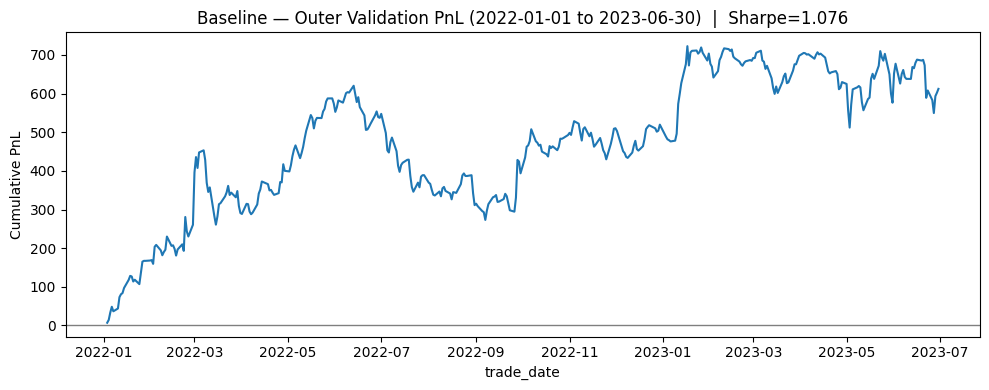

In [99]:
inner_val_preds = preds_baseline.attrs.get('inner_val_preds')

if inner_val_preds is None:
    print('No inner_val_preds found — redeploy modal_train.py and rerun the baseline cell.')
else:
    inner_dd = inner_val_preds.copy()
    if 'ret_fopen' not in inner_dd.columns:
        inner_dd = inner_dd.merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')

    inner_bt = backtest(inner_dd, feature_col='pred', ret_col='ret_fopen')
    inner_years = sorted(pd.to_datetime(inner_dd['msgStamp']).dt.year.unique())
    inner_label = str(inner_years[0]) if len(inner_years) == 1 else f'{inner_years[0]}–{inner_years[-1]}'
    print(f'Baseline inner-val  Sharpe: {inner_bt["sharpe_ratio"]:.4f}  '
          f'Return: {inner_bt["average_return"]:.6f}  ({inner_label})')

    ax = inner_bt['cumulative_returns'].plot(
        figsize=(10, 4),
        title=f'Baseline — Inner Validation PnL, Training Period ({inner_label})  |  Sharpe={inner_bt["sharpe_ratio"]:.3f}',
    )
    ax.axhline(0, color='black', lw=1, alpha=0.5)
    ax.set_ylabel('Cumulative PnL')
    plt.tight_layout()
    plt.show()

real_dd = preds_baseline.merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')
real_bt = backtest(real_dd, feature_col='pred', ret_col='ret_fopen')
print(f'Baseline real-val   Sharpe: {real_bt["sharpe_ratio"]:.4f}  '
      f'Return: {real_bt["average_return"]:.6f}  (2022-01-01 to 2023-06-30)')

ax = real_bt['cumulative_returns'].plot(
    figsize=(10, 4),
    title=f'Baseline — Outer Validation PnL (2022-01-01 to 2023-06-30)  |  Sharpe={real_bt["sharpe_ratio"]:.3f}',
)
ax.axhline(0, color='black', lw=1, alpha=0.5)
ax.set_ylabel('Cumulative PnL')
plt.tight_layout()
plt.show()

## 2. Hyperparameter search — Stage 1

Most impactful XGBoost hyperparameters for financial regression:
- `max_depth`: controls tree complexity / overfitting
- `learning_rate`: step size; smaller requires more trees

Grid: `max_depth ∈ {2,4,6,8,10}` × `learning_rate ∈ {0.01, 0.05, 0.10, 0.20}` (20 configs)


In [103]:
stage1_grid = {
    'max_depth': [2, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.10, 0.20],
}

base_params = {
    'n_estimators': 500,
    'subsample': 0.6,
    'colsample_bytree': 0.8,
    'min_child_weight': 100,
    'reg_alpha': 0.1,
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'verbosity': 0,
}

stage1_results = []

stage1_handles = {}
for max_depth, lr in product(stage1_grid['max_depth'], stage1_grid['learning_rate']):
    params = {**base_params, 'max_depth': max_depth, 'learning_rate': lr}
    handle = train_xgboost_fixed_fn.spawn(
        xgb_params=params,
        train_end_year=XGB_TRAIN_END_YEAR,
        val_years=XGB_VAL_YEARS,
        val_start=XGB_VAL_START,
        val_end=XGB_VAL_END,
    )
    stage1_handles[(max_depth, lr)] = handle

print(f'Spawned {len(stage1_handles)} Stage 1 jobs in parallel. Collecting...')

for (max_depth, lr), handle in stage1_handles.items():
    preds = _load_preds(handle.get())
    dd = preds.merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')
    bt = backtest(dd, feature_col='pred', ret_col='ret_fopen')

    key = ('stage1', max_depth, lr)
    all_preds[key] = {
        'preds': preds,
        'sharpe': bt['sharpe_ratio'],
        'return': bt['average_return'],
        'eval_results': preds.attrs.get('eval_results', {}),
    }
    stage1_results.append({
        'max_depth': max_depth,
        'learning_rate': lr,
        'sharpe': bt['sharpe_ratio'],
        'return': bt['average_return'],
        'key': key,
    })
    print(f'max_depth={max_depth:2d}  lr={lr:.2f}  sharpe={bt["sharpe_ratio"]:.4f}  return={bt["average_return"]:.6f}')


Spawned 20 Stage 1 jobs in parallel. Collecting...
max_depth= 2  lr=0.01  sharpe=0.5112  return=0.000731
max_depth= 2  lr=0.05  sharpe=0.5215  return=0.000752
max_depth= 2  lr=0.10  sharpe=0.5523  return=0.000786
max_depth= 2  lr=0.20  sharpe=0.5752  return=0.000823
max_depth= 4  lr=0.01  sharpe=0.8058  return=0.001211
max_depth= 4  lr=0.05  sharpe=1.0755  return=0.001675
max_depth= 4  lr=0.10  sharpe=1.2430  return=0.002007
max_depth= 4  lr=0.20  sharpe=1.2661  return=0.001985
max_depth= 6  lr=0.01  sharpe=0.3170  return=0.000461
max_depth= 6  lr=0.05  sharpe=0.9017  return=0.001423
max_depth= 6  lr=0.10  sharpe=2.2522  return=0.003425
max_depth= 6  lr=0.20  sharpe=0.4922  return=0.000715
max_depth= 8  lr=0.01  sharpe=0.2704  return=0.000431
max_depth= 8  lr=0.05  sharpe=0.6321  return=0.001031
max_depth= 8  lr=0.10  sharpe=0.2955  return=0.000448
max_depth= 8  lr=0.20  sharpe=0.8930  return=0.001371
max_depth=10  lr=0.01  sharpe=0.1339  return=0.000214
max_depth=10  lr=0.05  sharpe=-

In [104]:
stage1_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'key'} for r in stage1_results])
print('Stage 1 — Sharpe (max_depth × learning_rate):')
display(pd.pivot_table(stage1_df, values='sharpe', index='max_depth', columns='learning_rate'))
print('Stage 1 — Return (max_depth × learning_rate):')
display(pd.pivot_table(stage1_df, values='return', index='max_depth', columns='learning_rate'))

Stage 1 — Sharpe (max_depth × learning_rate):


learning_rate,0.01,0.05,0.10,0.20
max_depth,,,,
2,0.511178,0.521531,0.552297,0.575174
4,0.805820,1.075522,1.243042,1.266146
6,0.317004,0.901732,2.252170,0.492205
8,0.270359,0.632081,0.295471,0.893038
10,0.133873,-0.025204,0.189770,0.914836


Stage 1 — Return (max_depth × learning_rate):


learning_rate,0.01,0.05,0.10,0.20
max_depth,,,,
2,0.000731,0.000752,0.000786,0.000823
4,0.001211,0.001675,0.002007,0.001985
6,0.000461,0.001423,0.003425,0.000715
8,0.000431,0.001031,0.000448,0.001371
10,0.000214,-0.000039,0.000279,0.001430


Best stage 1: max_depth=6, learning_rate=0.1
  Sharpe: 2.2522  Return: 0.003425


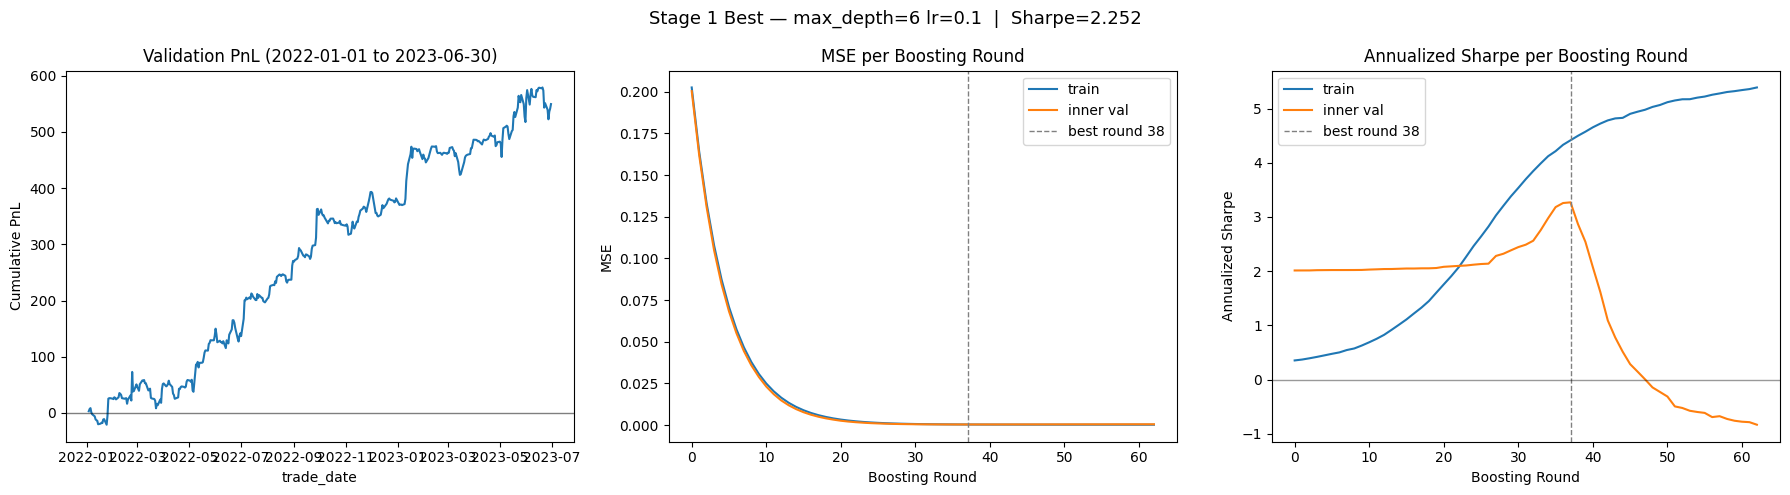

In [105]:
best_s1 = max(stage1_results, key=lambda r: r['sharpe'])
best_max_depth = best_s1['max_depth']
best_lr = best_s1['learning_rate']
print(f'Best stage 1: max_depth={best_max_depth}, learning_rate={best_lr}')
print(f'  Sharpe: {best_s1["sharpe"]:.4f}  Return: {best_s1["return"]:.6f}')

entry = all_preds[best_s1['key']]
dd = entry['preds'].merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')
bt = backtest(dd, feature_col='pred', ret_col='ret_fopen')
best_iter = entry['preds'].attrs.get('best_iteration')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Stage 1 Best — max_depth={best_max_depth} lr={best_lr}  |  Sharpe={bt["sharpe_ratio"]:.3f}', fontsize=13)

bt['cumulative_returns'].plot(ax=axes[0], title='Validation PnL (2022-01-01 to 2023-06-30)')
axes[0].axhline(0, color='black', lw=1, alpha=0.5)
axes[0].set_ylabel('Cumulative PnL')

er = entry['eval_results']
if er and 'train' in er:
    n_rounds = len(er['train']['mse'])
    stop = best_iter if best_iter is not None else n_rounds - 1

    axes[1].plot(er['train']['mse'], label='train')
    axes[1].plot(er['inner_val']['mse'], label='inner val')
    axes[1].axvline(stop, color='gray', lw=1, ls='--', label=f'best round {stop + 1}')
    axes[1].set_title('MSE per Boosting Round')
    axes[1].set_xlabel('Boosting Round')
    axes[1].set_ylabel('MSE')
    axes[1].legend()

    axes[2].plot(er['train']['sharpe'], label='train')
    axes[2].plot(er['inner_val']['sharpe'], label='inner val')
    axes[2].axvline(stop, color='gray', lw=1, ls='--', label=f'best round {stop + 1}')
    axes[2].axhline(0, color='black', lw=1, alpha=0.4)
    axes[2].set_title('Annualized Sharpe per Boosting Round')
    axes[2].set_xlabel('Boosting Round')
    axes[2].set_ylabel('Annualized Sharpe')
    axes[2].legend()
else:
    axes[1].set_visible(False)
    axes[2].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Hyperparameter search — Stage 2

Fix the best `max_depth` and `learning_rate` from Stage 1. Tune:
- `min_child_weight`: minimum sum of instance weight in a leaf (controls regularization)


In [106]:
stage2_grid = {
    'min_child_weight': [50, 100, 200],
}

stage2_results = []

stage2_handles = {}
for mcw in stage2_grid['min_child_weight']:
    params = {
        **base_params,
        'max_depth': best_max_depth,
        'learning_rate': best_lr,
        'min_child_weight': mcw,
    }
    handle = train_xgboost_fixed_fn.spawn(
        xgb_params=params,
        train_end_year=XGB_TRAIN_END_YEAR,
        val_years=XGB_VAL_YEARS,
        val_start=XGB_VAL_START,
        val_end=XGB_VAL_END,
    )
    stage2_handles[mcw] = handle

print(f'Spawned {len(stage2_handles)} Stage 2 jobs in parallel. Collecting...')

for mcw, handle in stage2_handles.items():
    preds = _load_preds(handle.get())
    dd = preds.merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')
    bt = backtest(dd, feature_col='pred', ret_col='ret_fopen')

    key = ('stage2', mcw)
    all_preds[key] = {
        'preds': preds,
        'sharpe': bt['sharpe_ratio'],
        'return': bt['average_return'],
        'eval_results': preds.attrs.get('eval_results', {}),
    }
    stage2_results.append({
        'min_child_weight': mcw,
        'sharpe': bt['sharpe_ratio'],
        'return': bt['average_return'],
        'key': key,
    })
    print(f'mcw={mcw:3d}  sharpe={bt["sharpe_ratio"]:.4f}  return={bt["average_return"]:.6f}')


Spawned 3 Stage 2 jobs in parallel. Collecting...
mcw= 50  sharpe=1.4729  return=0.002484
mcw=100  sharpe=2.2522  return=0.003425
mcw=200  sharpe=1.7600  return=0.002633


In [107]:
stage2_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'key'} for r in stage2_results])
print('Stage 2 — Results by min_child_weight:')
display(stage2_df.set_index('min_child_weight').sort_index())


Stage 2 — Results by min_child_weight:


,sharpe,return
min_child_weight,,
50,1.472936,0.002484
100,2.252170,0.003425
200,1.760027,0.002633


Best Stage 2: min_child_weight=100
Validation Sharpe: 2.2522  Return: 0.003425


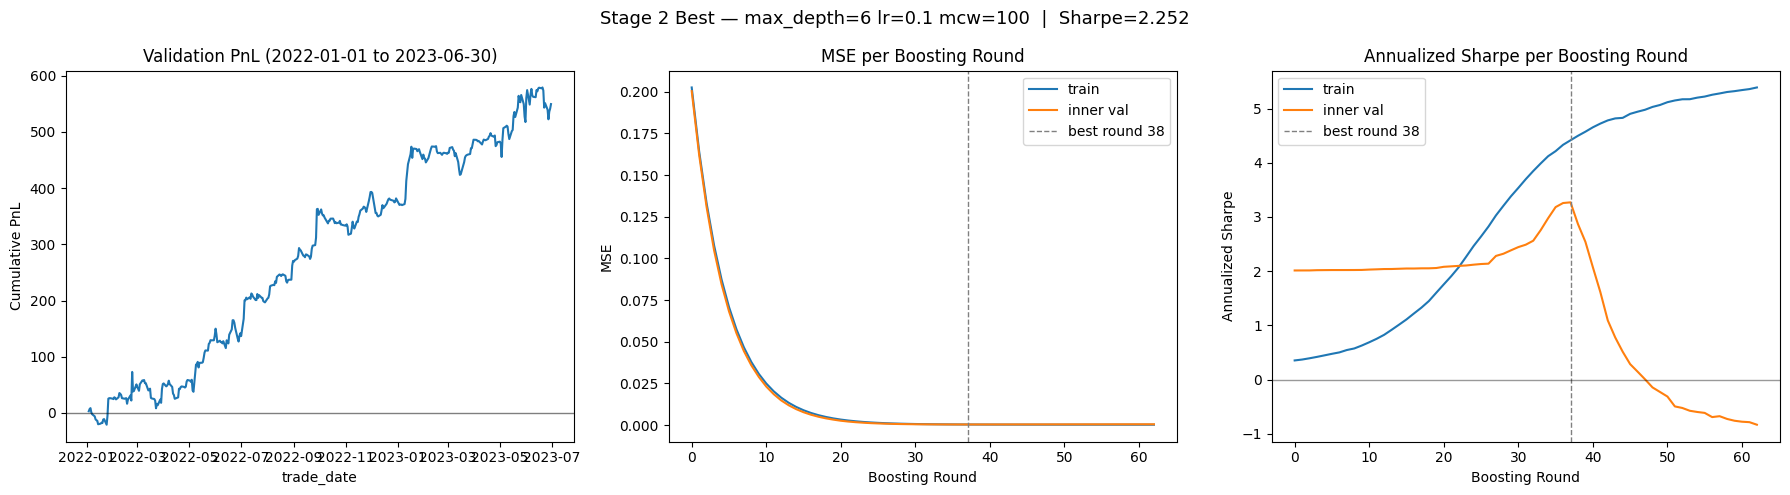

In [108]:
best_s2 = max(stage2_results, key=lambda r: r['sharpe'])
preds_xgb = all_preds[best_s2['key']]['preds']
print(f'Best Stage 2: min_child_weight={best_s2["min_child_weight"]}')
print(f'Validation Sharpe: {best_s2["sharpe"]:.4f}  Return: {best_s2["return"]:.6f}')

entry = all_preds[best_s2['key']]
dd = entry['preds'].merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')
bt = backtest(dd, feature_col='pred', ret_col='ret_fopen')
best_iter = entry['preds'].attrs.get('best_iteration')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'Stage 2 Best — max_depth={best_max_depth} lr={best_lr} mcw={best_s2["min_child_weight"]}  |  Sharpe={bt["sharpe_ratio"]:.3f}',
    fontsize=13,
)

bt['cumulative_returns'].plot(ax=axes[0], title='Validation PnL (2022-01-01 to 2023-06-30)')
axes[0].axhline(0, color='black', lw=1, alpha=0.5)
axes[0].set_ylabel('Cumulative PnL')

er = entry['eval_results']
if er and 'train' in er:
    n_rounds = len(er['train']['mse'])
    stop = best_iter if best_iter is not None else n_rounds - 1

    axes[1].plot(er['train']['mse'], label='train')
    axes[1].plot(er['inner_val']['mse'], label='inner val')
    axes[1].axvline(stop, color='gray', lw=1, ls='--', label=f'best round {stop + 1}')
    axes[1].set_title('MSE per Boosting Round')
    axes[1].set_xlabel('Boosting Round')
    axes[1].set_ylabel('MSE')
    axes[1].legend()

    axes[2].plot(er['train']['sharpe'], label='train')
    axes[2].plot(er['inner_val']['sharpe'], label='inner val')
    axes[2].axvline(stop, color='gray', lw=1, ls='--', label=f'best round {stop + 1}')
    axes[2].axhline(0, color='black', lw=1, alpha=0.4)
    axes[2].set_title('Annualized Sharpe per Boosting Round')
    axes[2].set_xlabel('Boosting Round')
    axes[2].set_ylabel('Annualized Sharpe')
    axes[2].legend()
else:
    axes[1].set_visible(False)
    axes[2].set_visible(False)

plt.tight_layout()
plt.show()

with open('preds_xgboost.pkl', 'wb') as f:
    _pickle.dump(preds_xgb, f)


## 4. Test period evaluation (train through validation end, predict from 2023-07-01)

After validation/search, train the selected XGBoost configuration through `2023-06-30` and predict from `2023-07-01` onward.
This matches the transformer protocol: validation rows are allowed in final training, and test rows are held out.


In [109]:
if 'best_s2' in globals() and 'min_child_weight' in best_s2:
    final_xgb_params = {
        **base_params,
        'max_depth': best_max_depth,
        'learning_rate': best_lr,
        'min_child_weight': best_s2['min_child_weight'],
    }
elif 'best_s1' in globals():
    final_xgb_params = {
        **base_params,
        'max_depth': best_max_depth,
        'learning_rate': best_lr,
    }
else:
    final_xgb_params = baseline_params

FINAL_XGB_TRAIN_END_DATE = XGB_VAL_END
FINAL_XGB_TRAIN_END_YEAR = int(FINAL_XGB_TRAIN_END_DATE[:4])

print(
    f'Running final XGBoost test model '
    f'(train through {FINAL_XGB_TRAIN_END_DATE}, test from {XGB_TEST_START})...'
)
print(f'Params: {final_xgb_params}')

preds_xgb_test = _load_preds(train_xgboost_fixed_fn.remote(
    xgb_params=final_xgb_params,
    train_end_year=FINAL_XGB_TRAIN_END_YEAR,
    train_end_date=FINAL_XGB_TRAIN_END_DATE,
    val_years=[FINAL_XGB_TRAIN_END_YEAR],
    val_start=XGB_TEST_START,
    val_end=XGB_TEST_END,
    verbose=True,
))

dd_test = preds_xgb_test.merge(df[['msgStamp', 'ret_fopen']], on='msgStamp', how='left')
bt_test = backtest(dd_test, feature_col='pred', ret_col='ret_fopen')
test_label = _pred_date_range_label(preds_xgb_test) if '_pred_date_range_label' in globals() else 'test period'

print(f'Test Sharpe : {bt_test["sharpe_ratio"]:.4f}  ({test_label})')
print(f'Test Return : {bt_test["average_return"]:.6f}')


Running final XGBoost test model (train through 2023-06-30, test from 2023-07-01)...
Params: {'n_estimators': 500, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 100, 'reg_alpha': 0.1, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'verbosity': 0, 'max_depth': 6, 'learning_rate': 0.1}
Test Sharpe : 0.6851  (test period)
Test Return : 0.000616


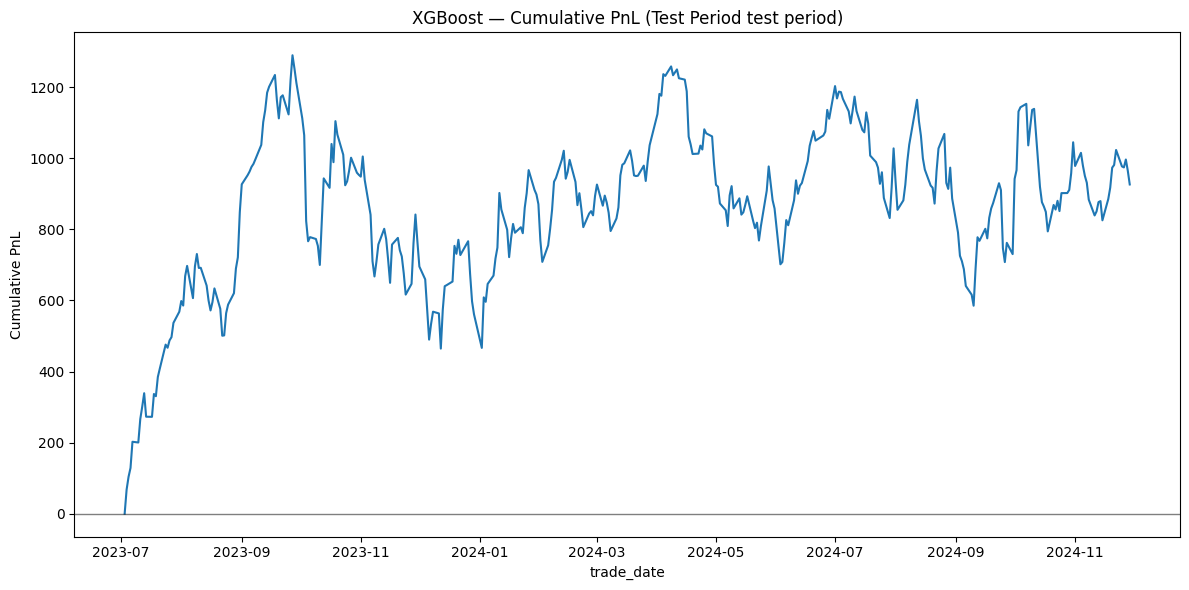

In [110]:
ax = bt_test['cumulative_returns'].plot(
    figsize=(12, 6), title=f'XGBoost — Cumulative PnL (Test Period {test_label})'
)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.set_ylabel('Cumulative PnL')
plt.tight_layout()
plt.show()
